# Gene Expression Cancer Data Analysis

### Loading and Initial Exploration

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('E:\Research on cancer\gene expression RNA seq data.csv')

print(df.shape)
print(df.head())

<>:7: SyntaxWarning: invalid escape sequence '\R'
<>:7: SyntaxWarning: invalid escape sequence '\R'
C:\Users\khan\AppData\Local\Temp\ipykernel_291380\1545620037.py:7: SyntaxWarning: invalid escape sequence '\R'
  df = pd.read_csv('E:\Research on cancer\gene expression RNA seq data.csv')


(801, 20532)
  Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0   sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0   
1   sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0   
2   sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0   
3   sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0   
4   sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0   

     gene_6    gene_7  gene_8  ...  gene_20521  gene_20522  gene_20523  \
0  7.175175  0.591871     0.0  ...    4.926711    8.210257    9.723516   
1  6.816049  0.000000     0.0  ...    4.593372    7.323865    9.740931   
2  6.972130  0.452595     0.0  ...    5.125213    8.127123   10.908640   
3  7.843375  0.434882     0.0  ...    6.076566    8.792959   10.141520   
4  6.566967  0.360982     0.0  ...    5.996032    8.891425   10.373790   

   gene_20524  gene_20525  gene_20526  gene_20527  gene_20528  gene_20529  \
0    7.220030    9.119813 

### Data Quality Check

In [8]:
# Check missing values
print("Missing values:", df.isnull().sum().sum())

# Check data types
print("\nData types:")
print(df.dtypes.value_counts())

# Basic statistics
print("\nBasic stats:")
print(df.iloc[:, 1:6].describe())

# Check if labels file exists
import os
files = os.listdir(os.getcwd())
for f in files:
    if 'label' in f.lower() or 'class' in f.lower():
        print("Found label file:", f)

Missing values: 0

Data types:
float64    20531
object         1
Name: count, dtype: int64

Basic stats:
           gene_0      gene_1      gene_2      gene_3      gene_4
count  801.000000  801.000000  801.000000  801.000000  801.000000
mean     0.026642    3.010909    3.095350    6.722305    9.813612
std      0.136850    1.200828    1.065601    0.638819    0.506537
min      0.000000    0.000000    0.000000    5.009284    8.435999
25%      0.000000    2.299039    2.390365    6.303346    9.464466
50%      0.000000    3.143687    3.127006    6.655893    9.791599
75%      0.000000    3.883484    3.802534    7.038447   10.142324
max      1.482332    6.237034    6.063484   10.129528   11.355621
Found label file: Bioinformatics class 1.ipynb
Found label file: Bioinformatics class 2.ipynb


### Load Cancer Type Labels

In [10]:
# Load labels
labels = pd.read_csv('E:\Research on cancer\labels.csv')

print(labels.shape)
print(labels.head())
print("\nCancer types:")
print(labels.iloc[:, 1].value_counts())

(801, 2)
  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA

Cancer types:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\khan\AppData\Local\Temp\ipykernel_291380\2133106120.py:2: SyntaxWarning: invalid escape sequence '\R'
  labels = pd.read_csv('E:\Research on cancer\labels.csv')


### Merge Gene Expression Data with Cancer Labels

In [11]:
# Rename column for clarity
labels.columns = ['sample_id', 'cancer_type']
df.rename(columns={'Unnamed: 0': 'sample_id'}, inplace=True)

# Merge
df_merged = pd.merge(df, labels, on='sample_id')

print("Merged shape:", df_merged.shape)
print(df_merged[['sample_id', 'cancer_type']].head())

Merged shape: (801, 20533)
  sample_id cancer_type
0  sample_0        PRAD
1  sample_1        LUAD
2  sample_2        PRAD
3  sample_3        PRAD
4  sample_4        BRCA


### Cancer Type Distribution

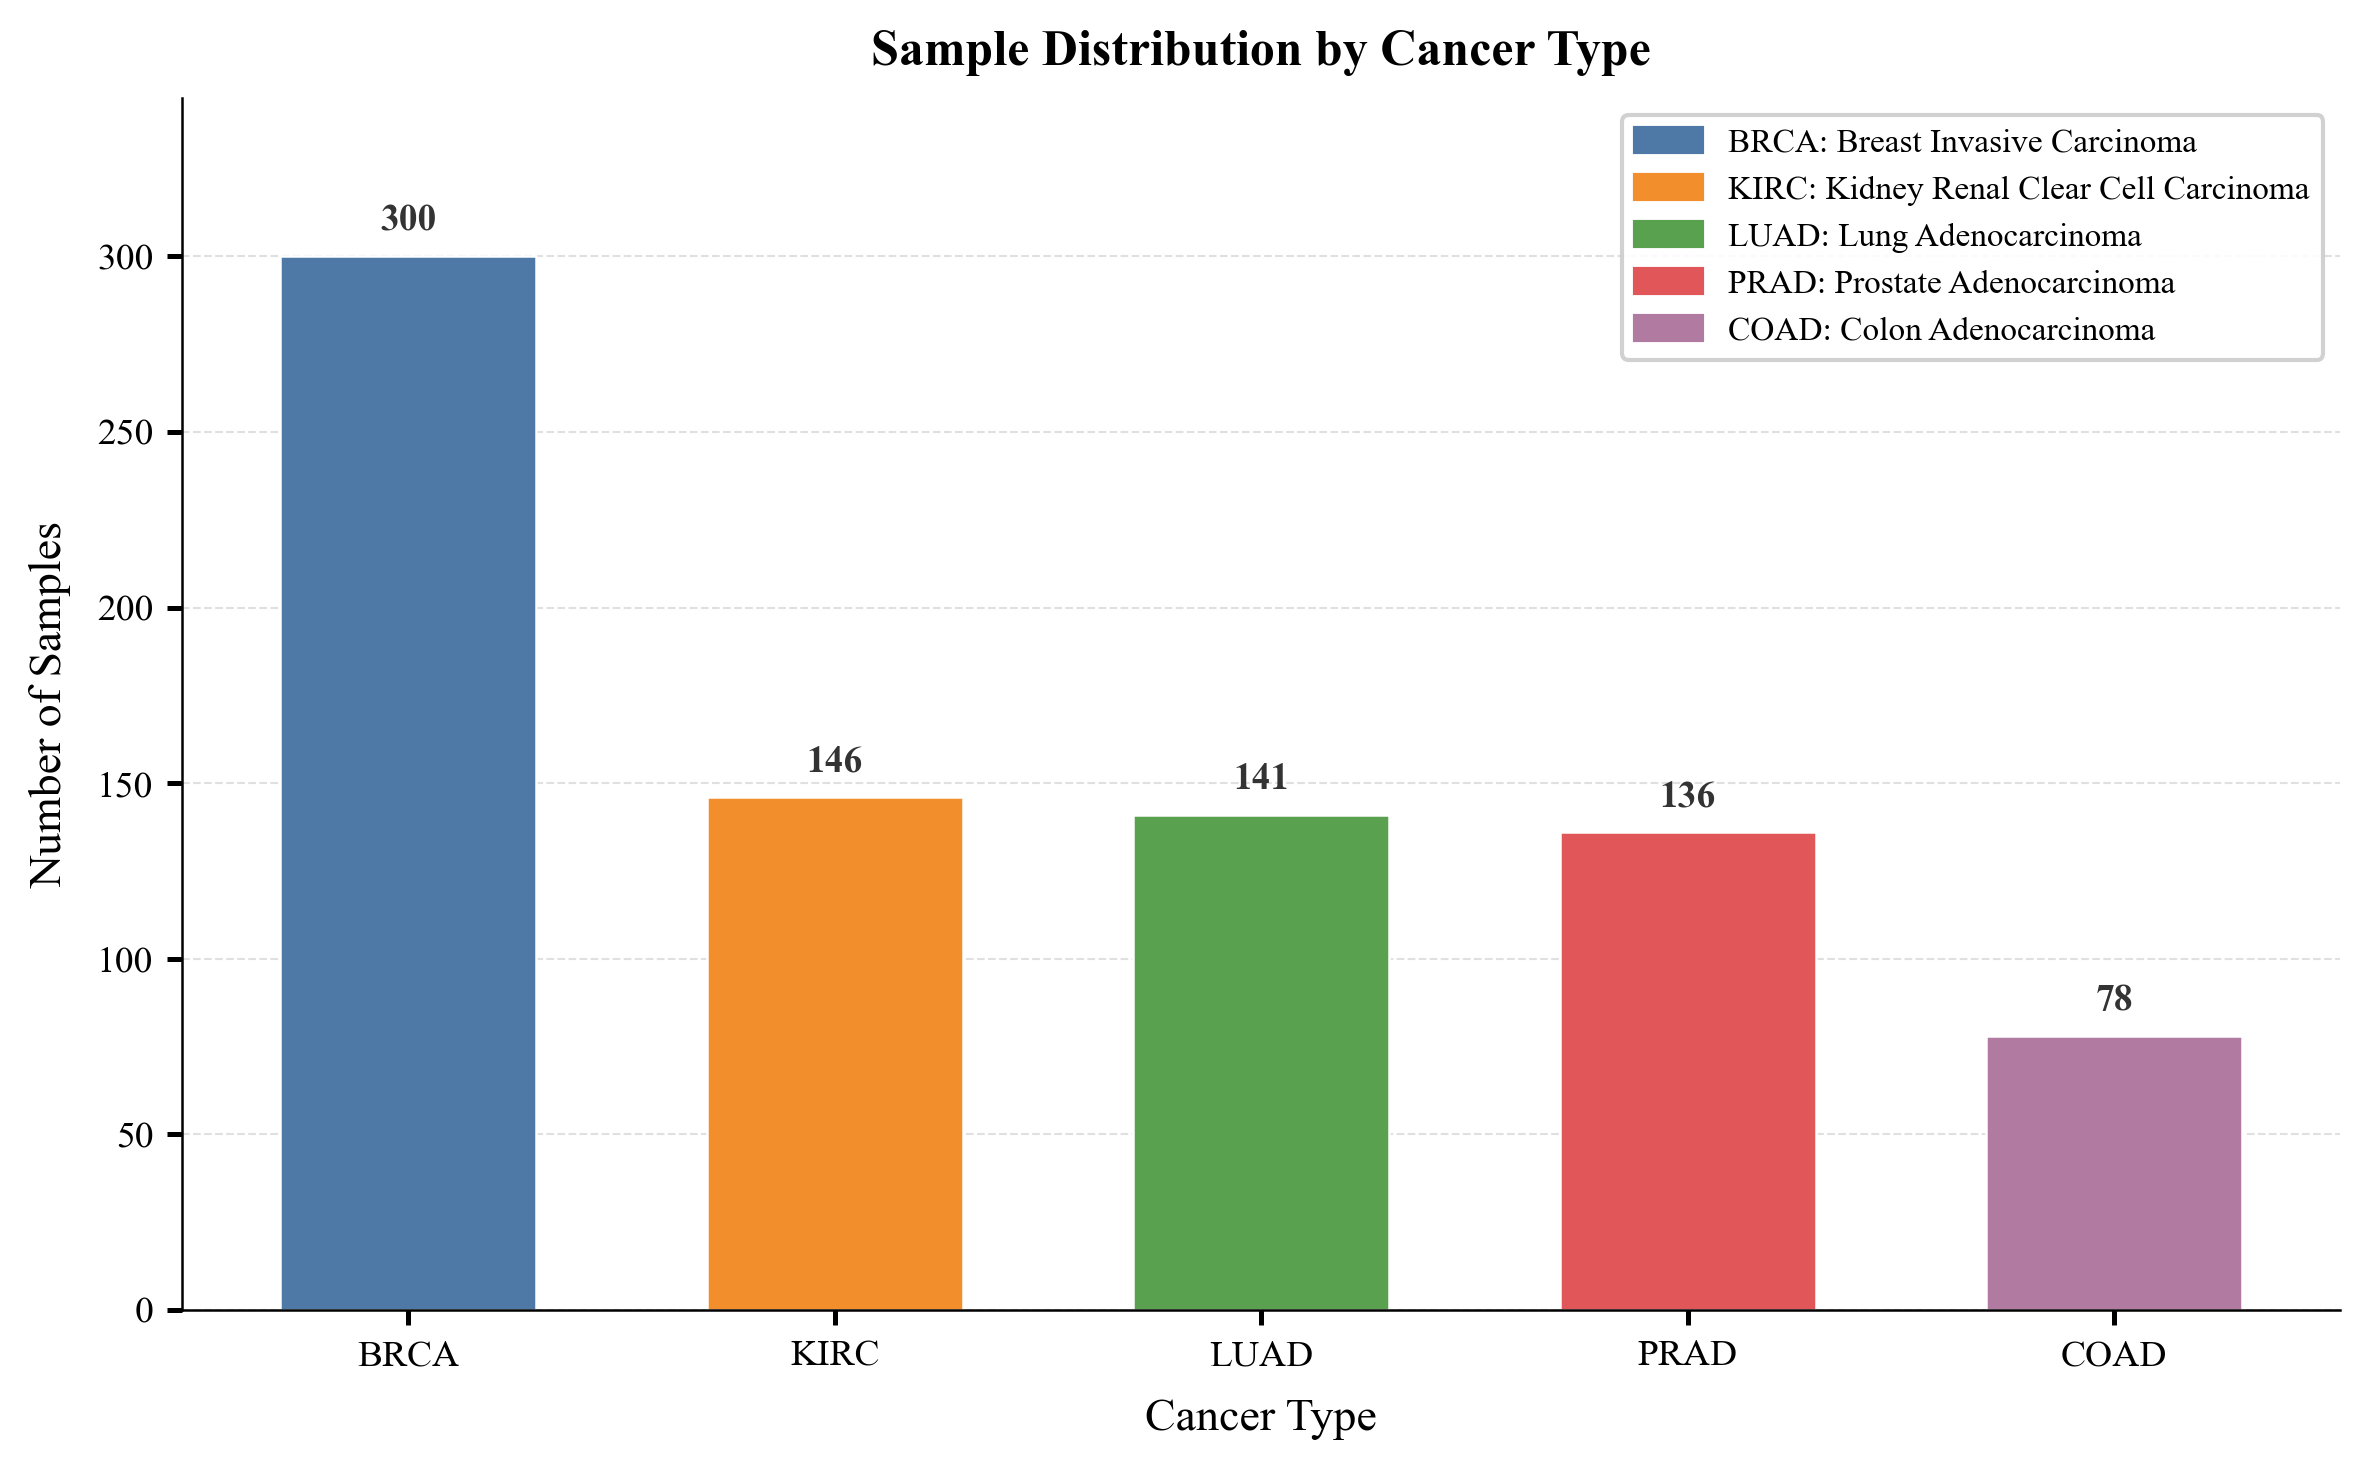

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

cancer_counts = df_merged['cancer_type'].value_counts()

colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(cancer_counts.index, cancer_counts.values,
              color=colors, width=0.6, edgecolor='white', linewidth=0.6)

# Value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 5,
            f'{int(height)}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='0.2')

ax.set_title('Sample Distribution by Cancer Type', pad=8)
ax.set_xlabel('Cancer Type', labelpad=6)
ax.set_ylabel('Number of Samples', labelpad=6)

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='0.85', alpha=0.8)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

# Set y-axis upper limit to give breathing room for labels
ax.set_ylim(0, max(cancer_counts.values) * 1.15)

legend_labels = [
    'BRCA: Breast Invasive Carcinoma',
    'KIRC: Kidney Renal Clear Cell Carcinoma',
    'LUAD: Lung Adenocarcinoma',
    'PRAD: Prostate Adenocarcinoma',
    'COAD: Colon Adenocarcinoma',
]
handles = [mpatches.Patch(color=colors[i]) for i in range(5)]
ax.legend(handles, legend_labels,
          loc='upper right',
          fontsize=8,
          frameon=True,
          edgecolor='0.8',
          framealpha=0.9)

plt.tight_layout()
plt.savefig('Figure1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('Figure1.pdf', bbox_inches='tight', facecolor='white')
plt.show()

### Heatmap of Top 50 Most Variable Genes

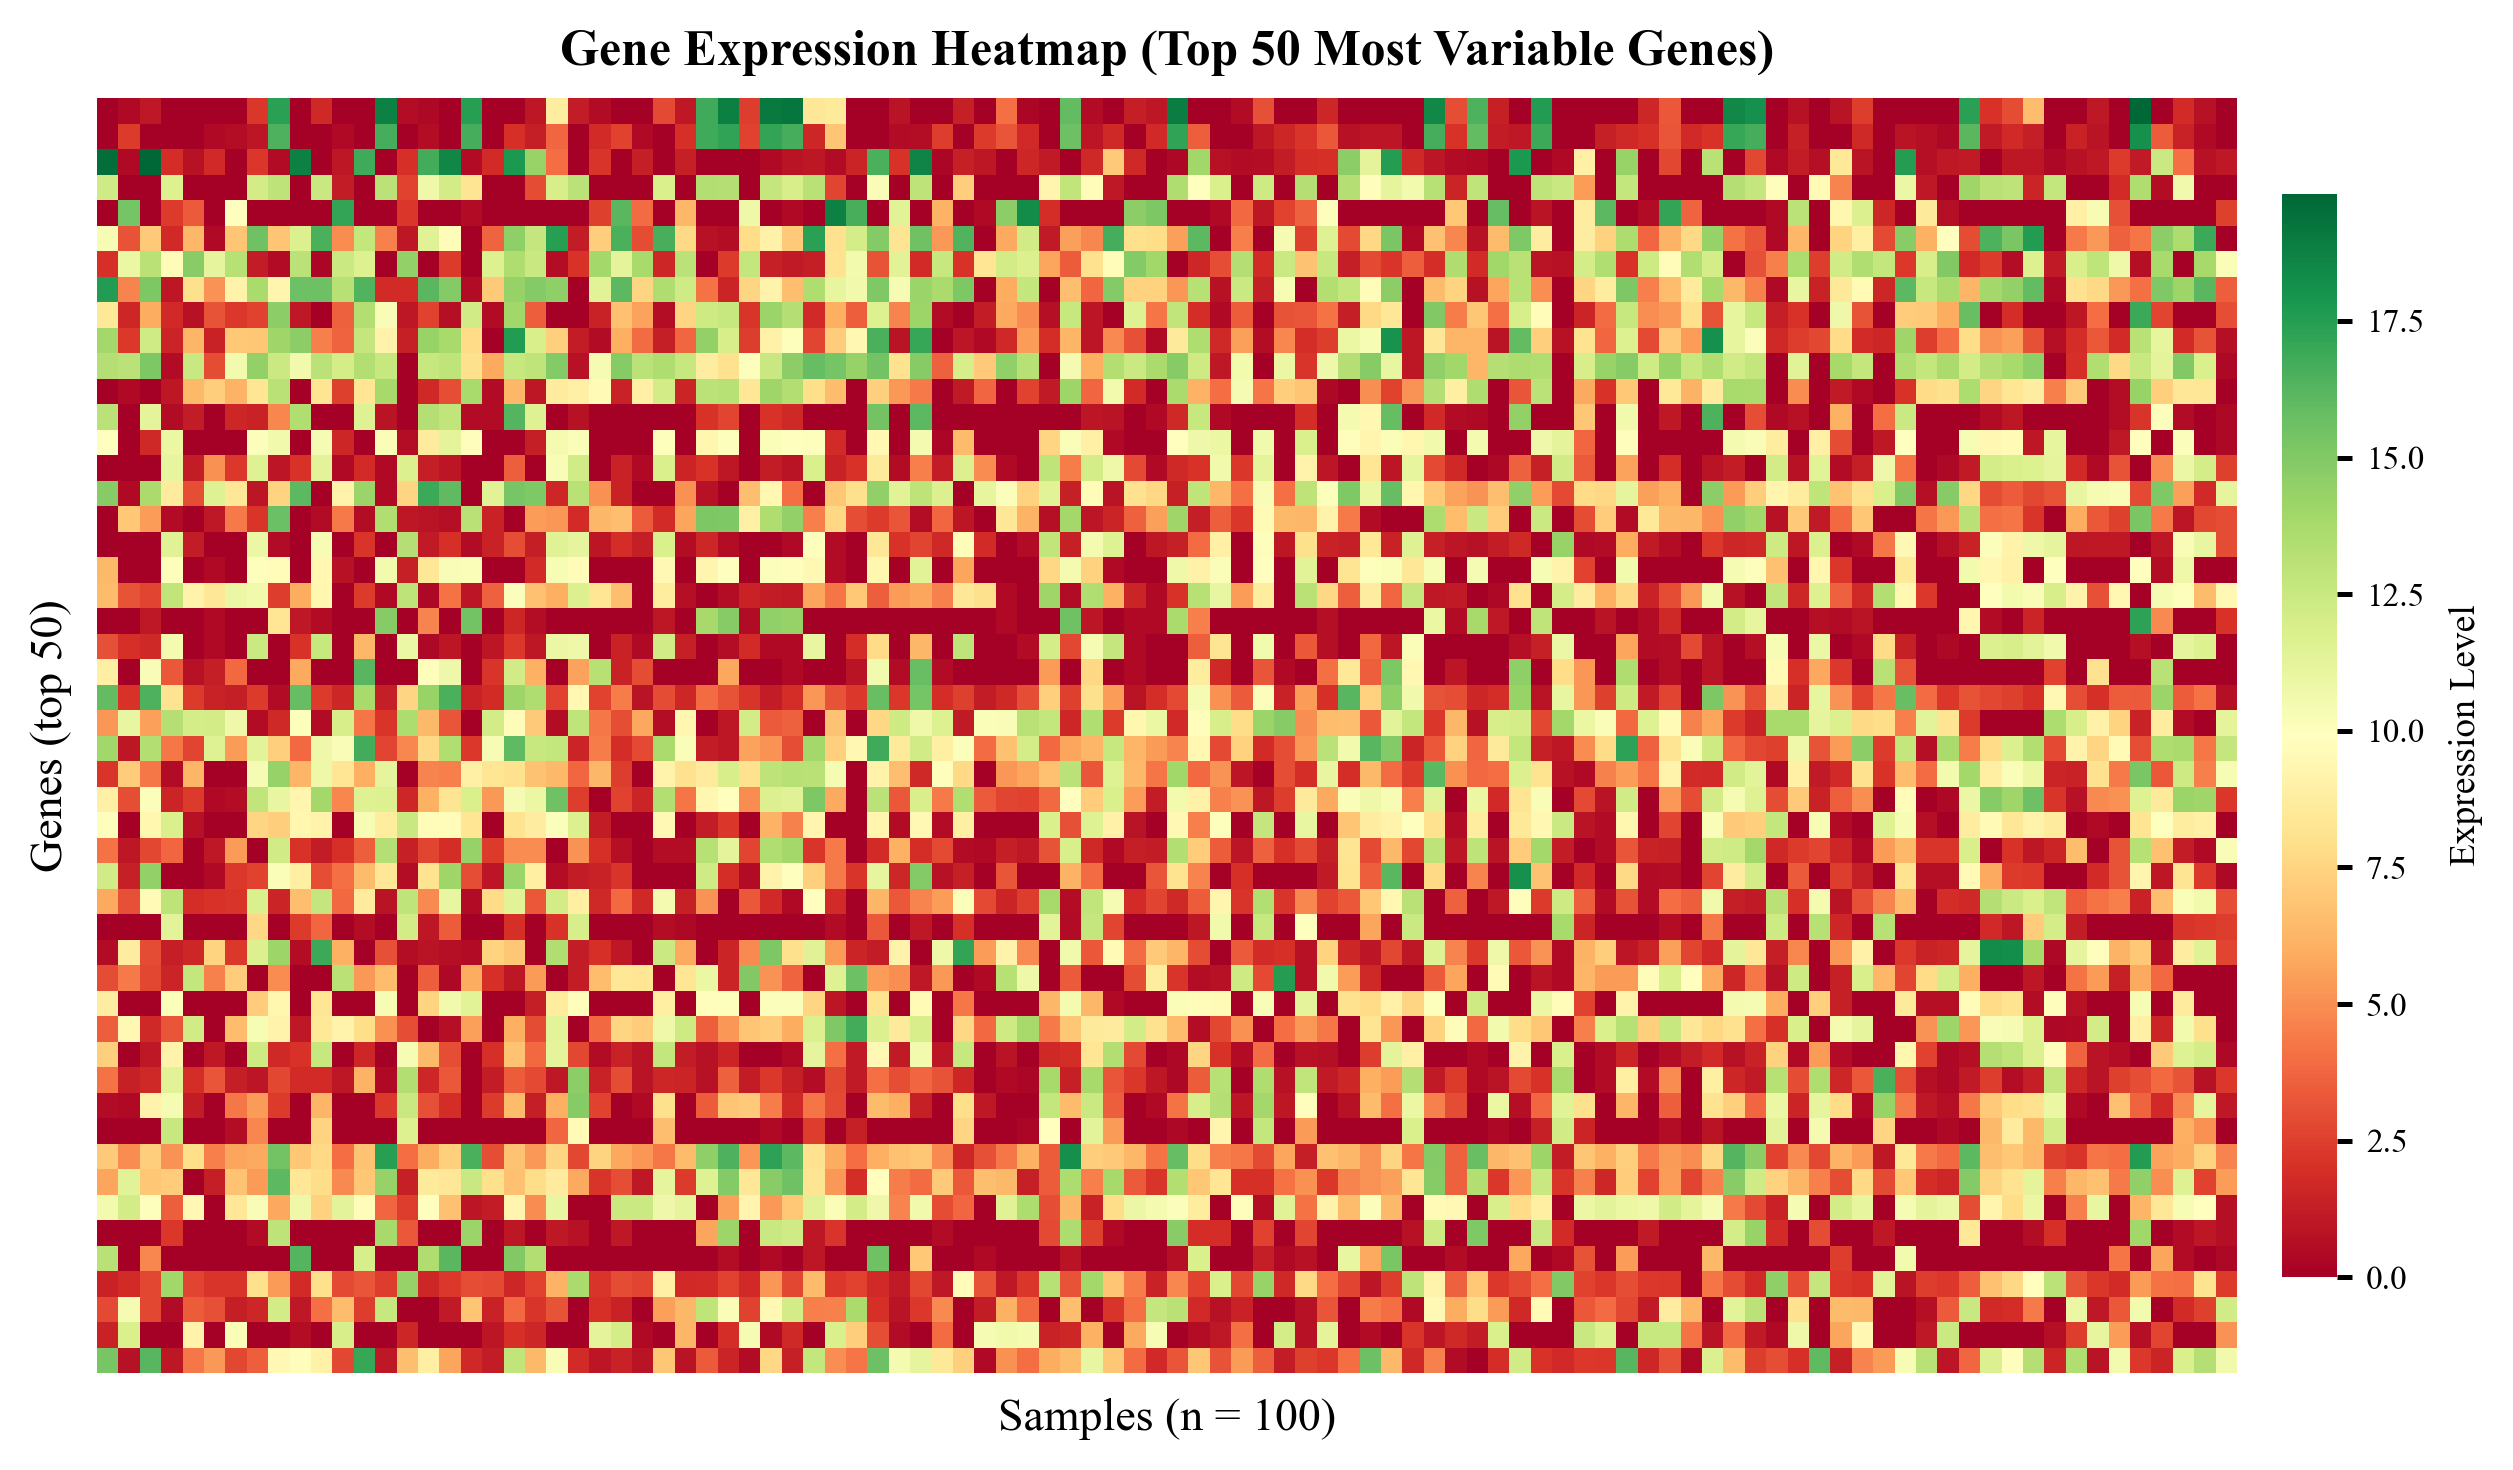

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Get gene columns only
gene_cols = [col for col in df_merged.columns if col.startswith('gene_')]

# Find top 50 most variable genes
gene_variance = df_merged[gene_cols].var().nlargest(50).index

# Sample 100 rows for cleaner visualization
df_sample = df_merged.sample(100, random_state=42)

# Create heatmap data
heatmap_data = df_sample[gene_variance].T

fig, ax = plt.subplots(figsize=(8.5, 5))

cbar_kws = {
    'label': 'Expression Level',
    'shrink': 0.85,
    'pad': 0.02,
    'fraction': 0.04,
}

hm = sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',
    xticklabels=False,
    yticklabels=False,
    cbar_kws=cbar_kws,
    linewidths=0,
    rasterized=True,
    ax=ax,
)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Expression Level', size=9, labelpad=6)

ax.set_title('Gene Expression Heatmap (Top 50 Most Variable Genes)', pad=8)
ax.set_xlabel('Samples (n = 100)', labelpad=6)
ax.set_ylabel('Genes (top 50)', labelpad=6)

for spine in ax.spines.values():
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.savefig('Figure2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('Figure2.pdf', bbox_inches='tight', facecolor='white')
plt.show()

### Average Gene Expression by Cancer Type

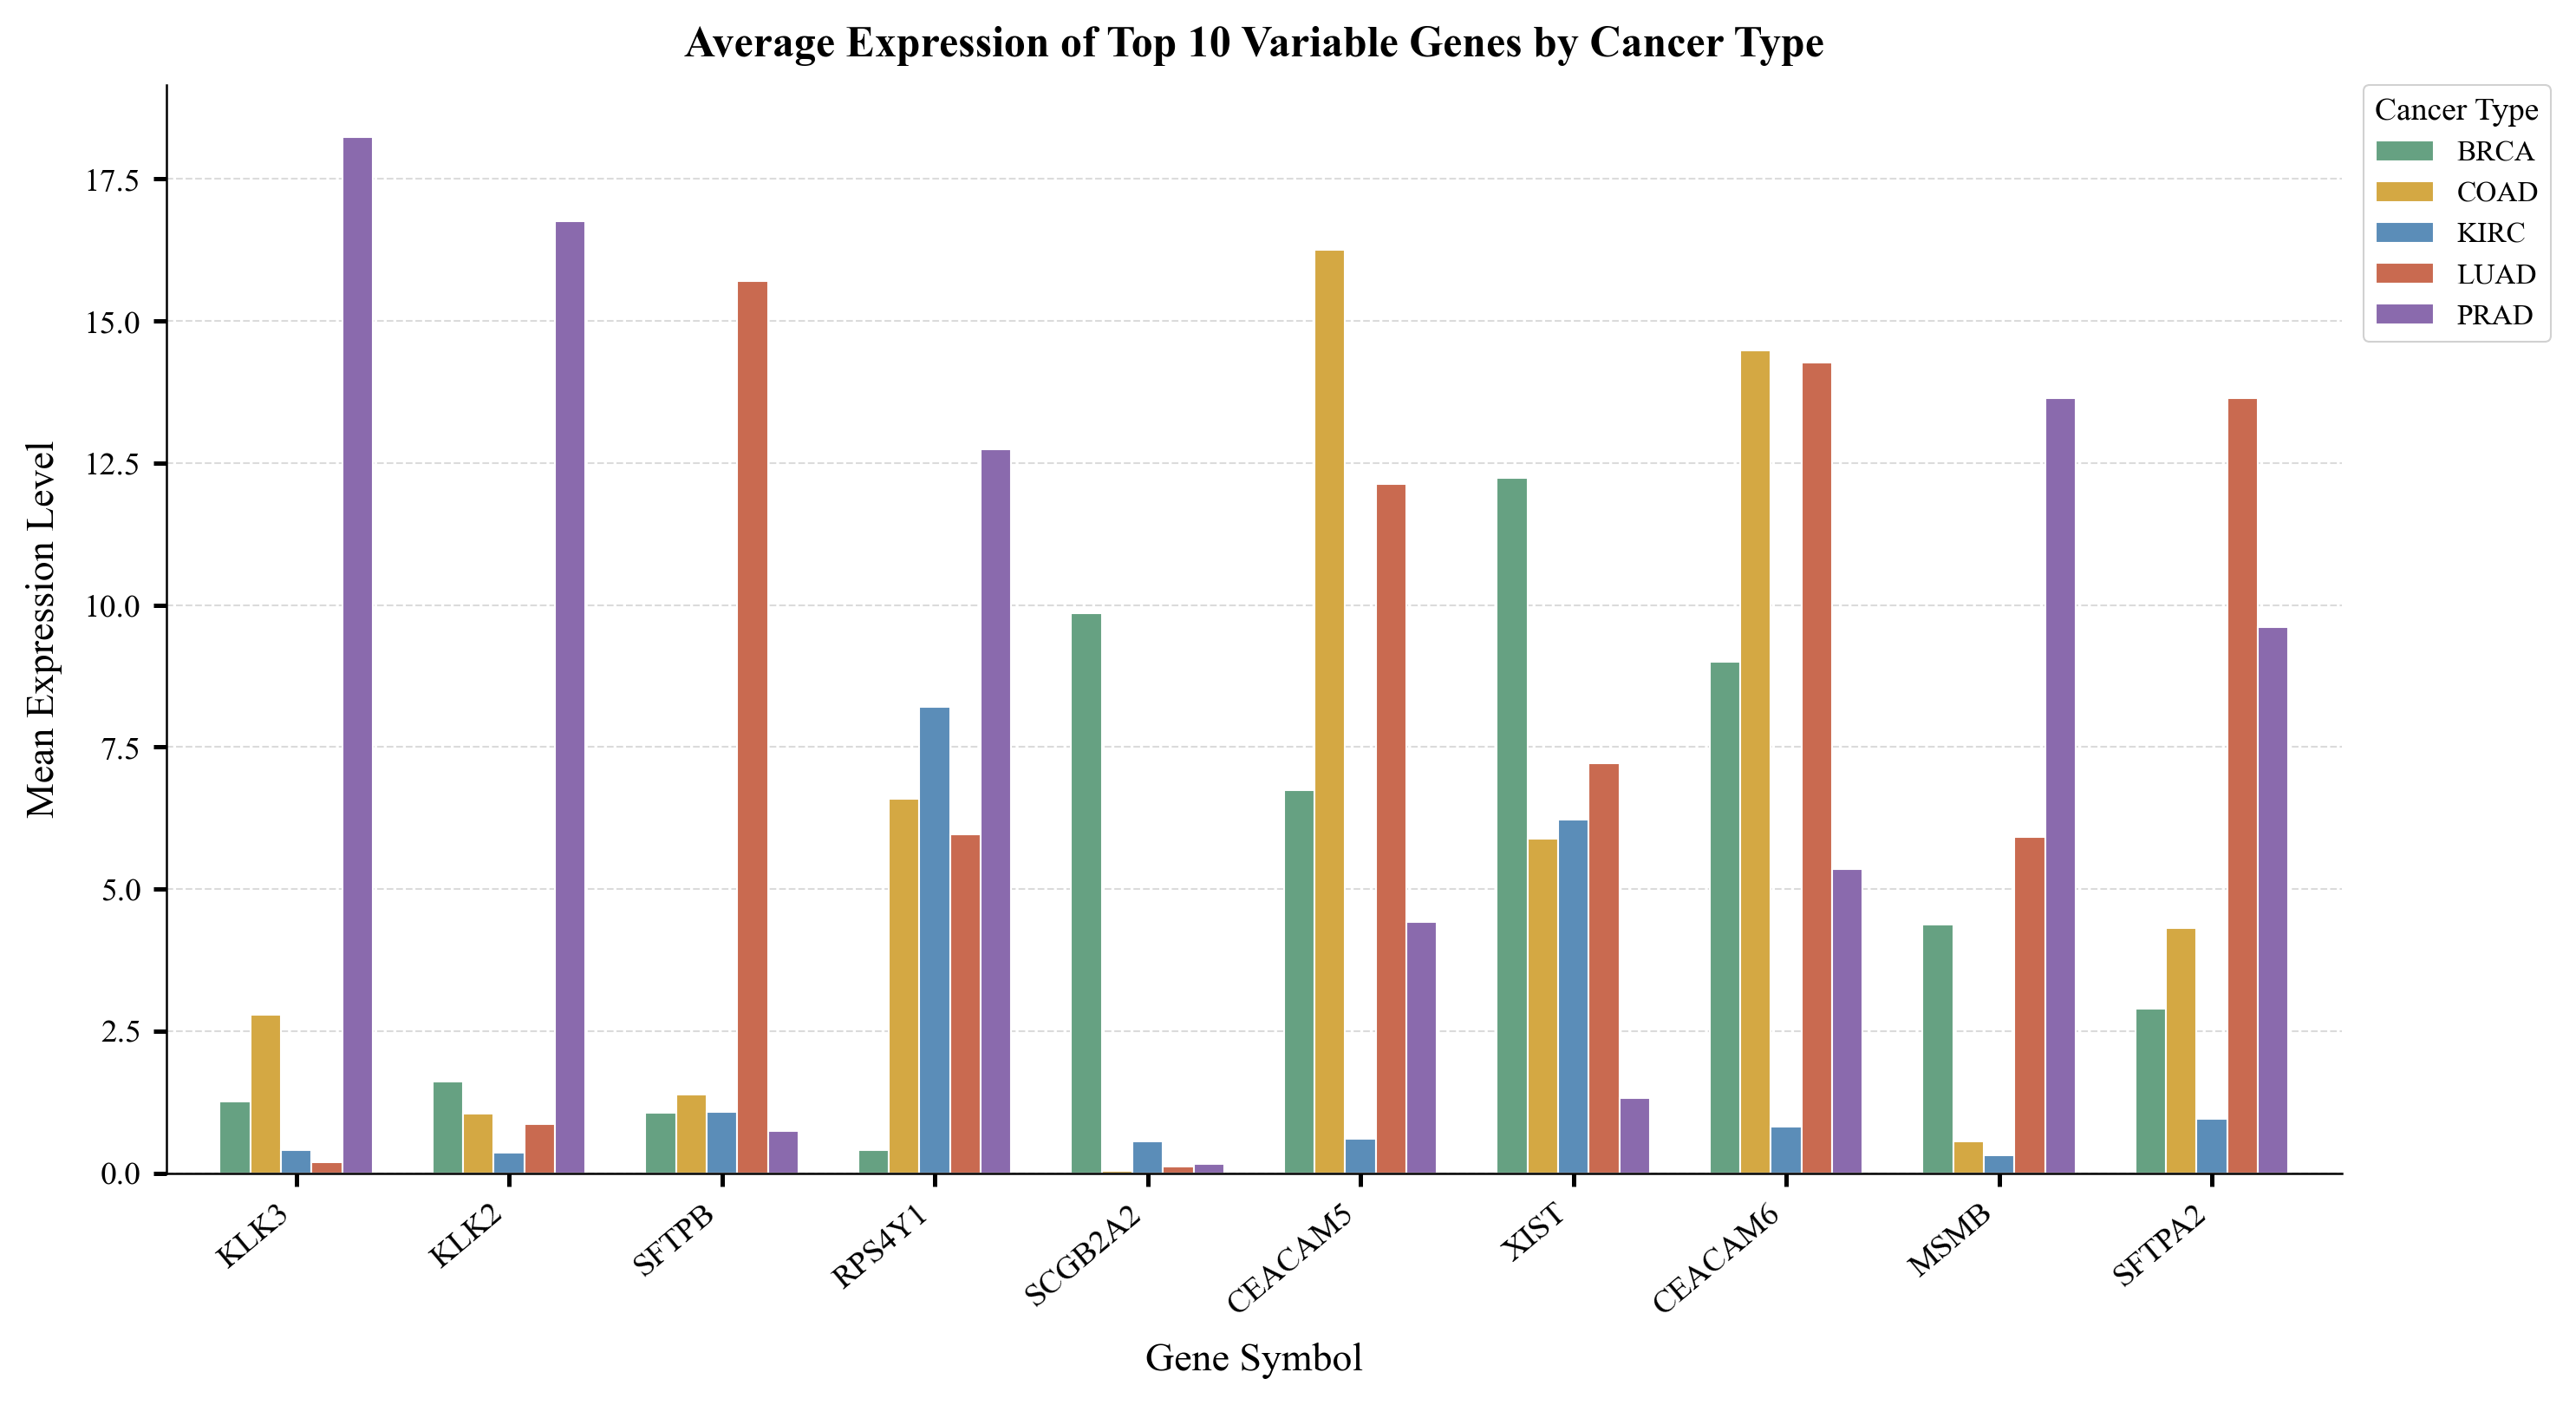

In [14]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'legend.frameon': True,
    'legend.edgecolor': '0.8',
    'legend.framealpha': 0.9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

rename_map = {
    'gene_9176': 'KLK3',
    'gene_9175': 'KLK2',
    'gene_15898': 'SFTPB',
    'gene_15301': 'RPS4Y1',
    'gene_15589': 'SCGB2A2',
    'gene_3540': 'CEACAM5',
    'gene_19661': 'XIST',
    'gene_3541': 'CEACAM6',
    'gene_11250': 'MSMB',
    'gene_15897': 'SFTPA2'
}

df_merged_named = df_merged.rename(columns=rename_map)

top10_genes_named = ['KLK3', 'KLK2', 'SFTPB', 'RPS4Y1', 'SCGB2A2',
                     'CEACAM5', 'XIST', 'CEACAM6', 'MSMB', 'SFTPA2']

cancer_gene_mean = df_merged_named.groupby('cancer_type')[top10_genes_named].mean()

palette = ['#66A182', '#D4A843', '#5B8DB8', '#C96A50', '#8A6AAD']

fig, ax = plt.subplots(figsize=(10, 5.5))

cancer_gene_mean.T.plot(
    kind='bar',
    ax=ax,
    color=palette,
    width=0.72,
    edgecolor='white',
    linewidth=0.5,
)

ax.set_title('Average Expression of Top 10 Variable Genes by Cancer Type', pad=8)
ax.set_xlabel('Gene Symbol', labelpad=6)
ax.set_ylabel('Mean Expression Level', labelpad=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='0.8', alpha=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

legend = ax.legend(
    title='Cancer Type',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0,
    title_fontsize=9,
    fontsize=8,
)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()
plt.savefig('Figure3.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('Figure3.pdf', bbox_inches='tight', facecolor='white')
plt.show()

### Gene Expression Distribution by Cancer Type

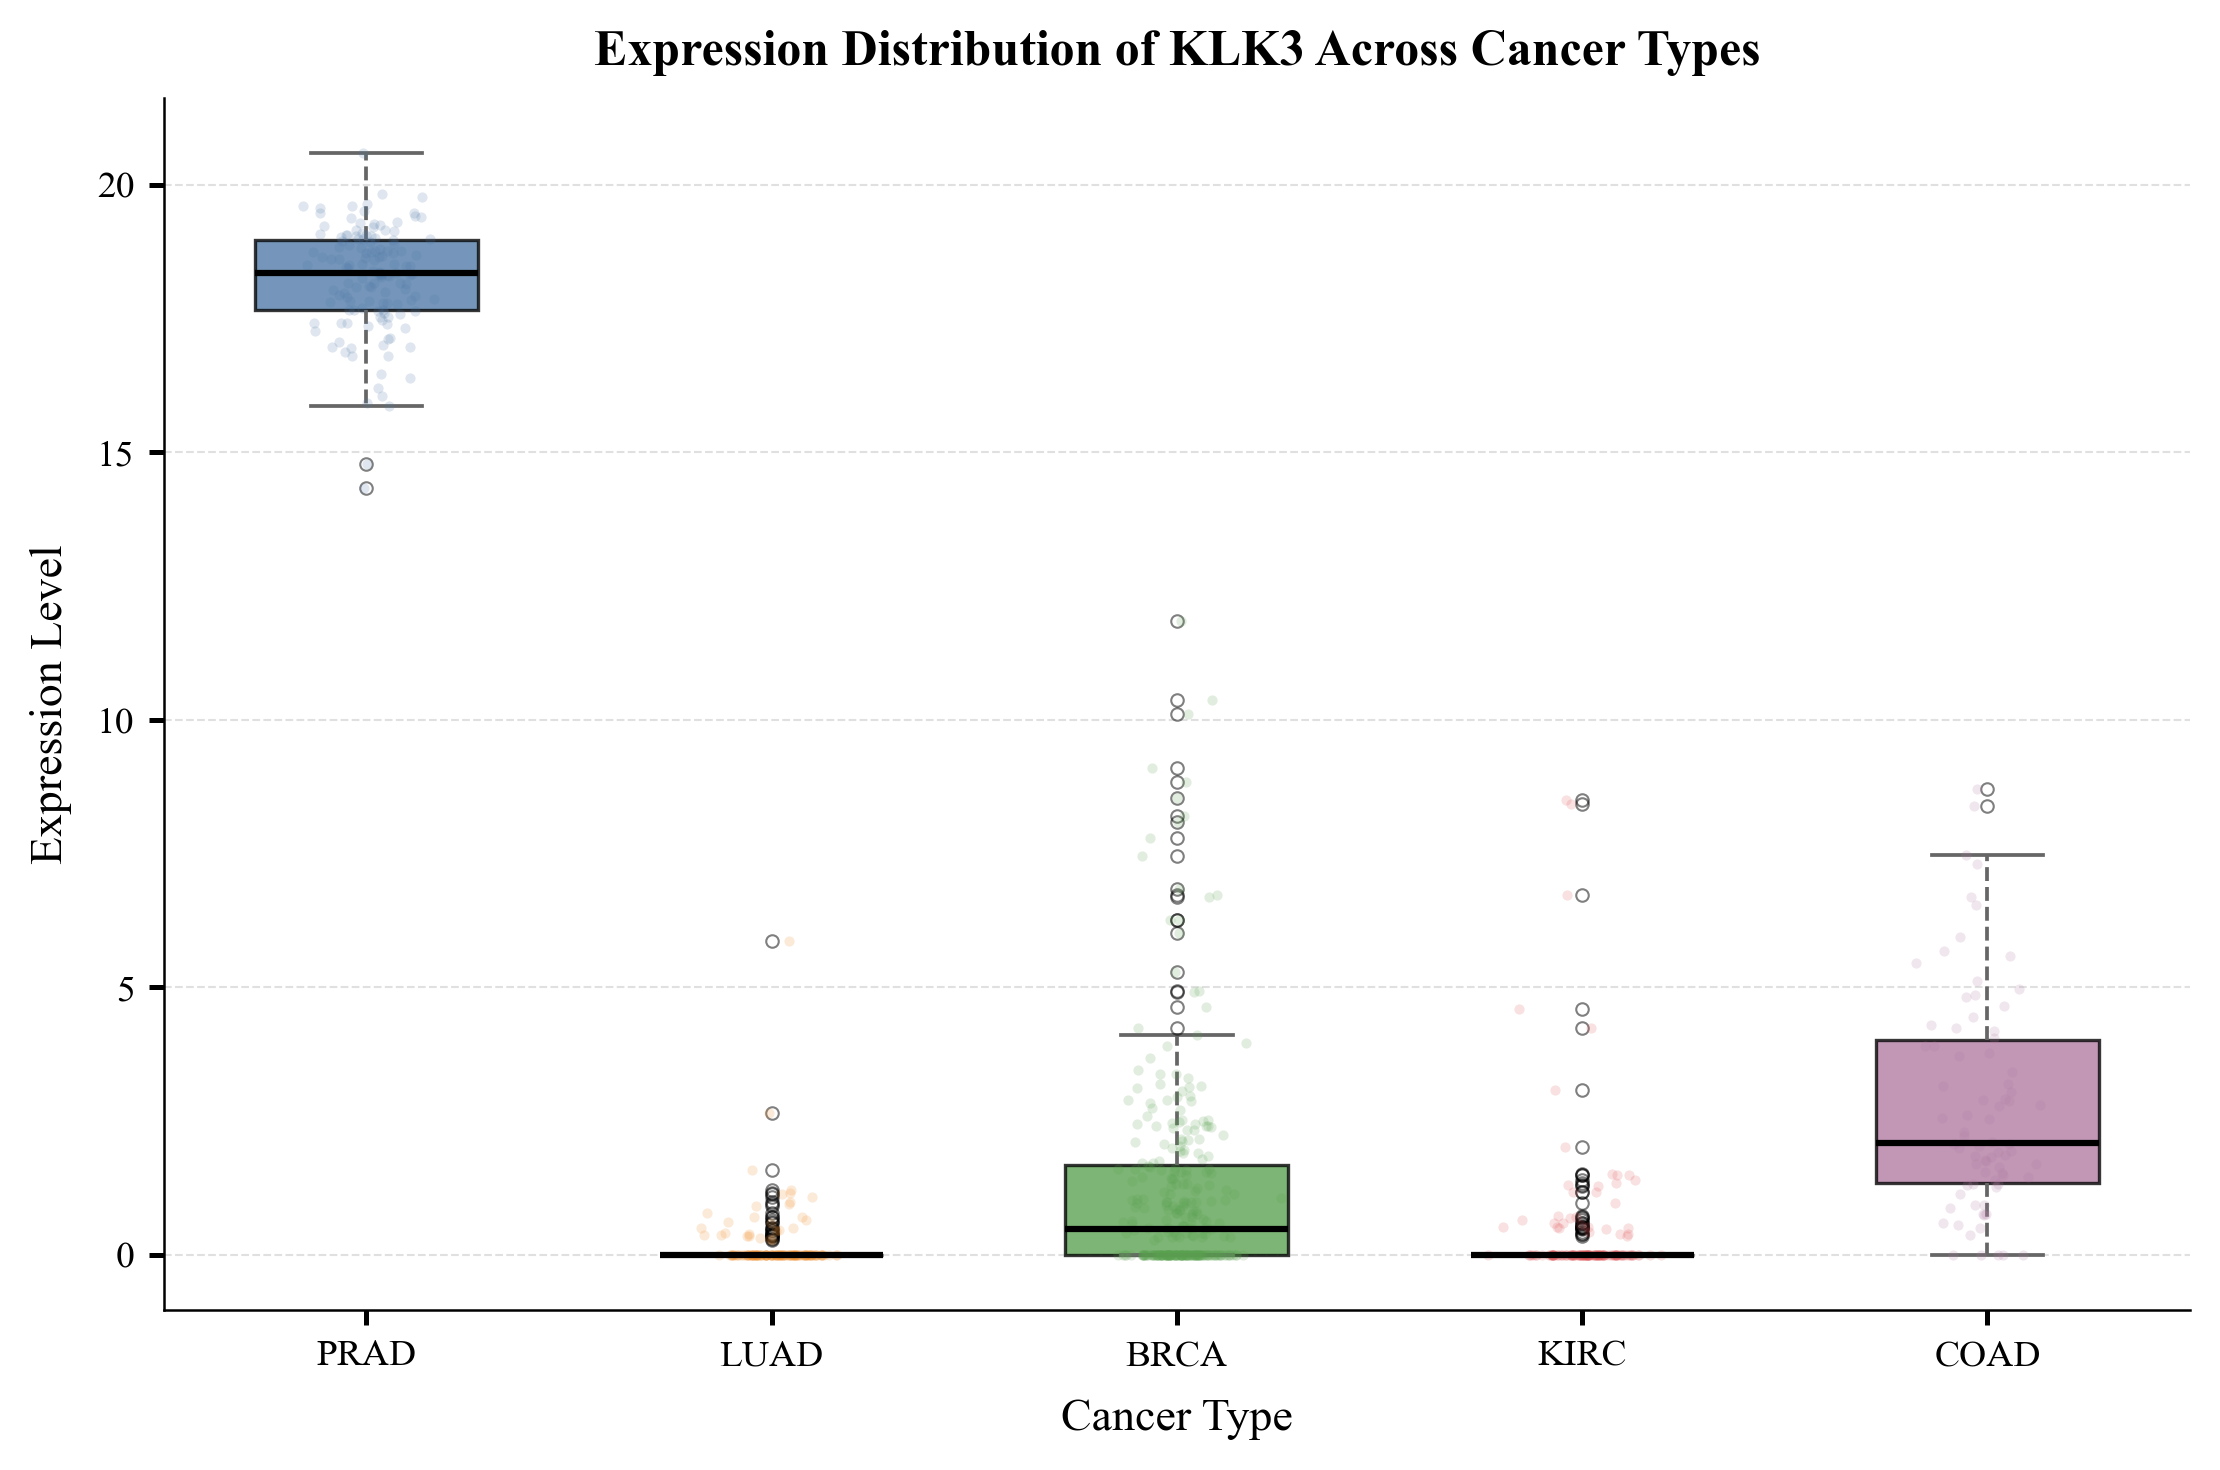

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

gene_cols = [col for col in df_merged.columns if col.startswith('gene_')]
top_gene = df_merged[gene_cols].var().nlargest(1).index[0]
cancer_types = df_merged['cancer_type'].unique()

colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1']

data_to_plot = [df_merged[df_merged['cancer_type'] == ct][top_gene].values
                for ct in cancer_types]

fig, ax = plt.subplots(figsize=(7.5, 5))

bp = ax.boxplot(
    data_to_plot,
    tick_labels=cancer_types,
    patch_artist=True,
    widths=0.55,
    notch=False,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=0.9, linestyle='--', color='0.4'),
    capprops=dict(linewidth=0.9, color='0.4'),
    flierprops=dict(marker='o', markersize=3, alpha=0.5, markeredgewidth=0.5),
    boxprops=dict(linewidth=0.8),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.78)

# Jitter overlay
for i, (ct, color) in enumerate(zip(cancer_types, colors), start=1):
    y = df_merged[df_merged['cancer_type'] == ct][top_gene].values
    x = np.random.normal(i, 0.07, size=len(y))
    ax.scatter(x, y, alpha=0.18, s=6, color=color, zorder=2, linewidths=0)

ax.set_title('Expression Distribution of KLK3 Across Cancer Types', pad=8)
ax.set_xlabel('Cancer Type', labelpad=6)
ax.set_ylabel('Expression Level', labelpad=6)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='0.85', alpha=0.8)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

plt.tight_layout()
plt.savefig('Figure4.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('Figure4.pdf', bbox_inches='tight', facecolor='white')
plt.show()

### Project Summary

In [11]:
print("=" * 55)
print("GENE EXPRESSION ANALYSIS SUMMARY")
print("=" * 55)
print(f"Total Samples: {df_merged.shape[0]}")
print(f"Total Genes Analyzed: {len(gene_cols)}")
print(f"Cancer Types: {df_merged['cancer_type'].nunique()}")
print(f"\nSamples per Cancer Type:")
print(df_merged['cancer_type'].value_counts().to_string())
print(f"\nMost Variable Gene: {top_gene}")
print(f"Missing Values: 0")
print("=" * 55)

GENE EXPRESSION ANALYSIS SUMMARY
Total Samples: 801
Total Genes Analyzed: 20531
Cancer Types: 5

Samples per Cancer Type:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78

Most Variable Gene: gene_9176
Missing Values: 0


### Statistical Profiling of Differential Gene Expression and Variability

In [12]:
# Top 10 most variable genes and their stats
top10 = df_merged[gene_cols].var().nlargest(10)
print("Top 10 Most Variable Genes:")
print(top10)

# Mean expression of gene_9176 per cancer type
print("\ngene_9176 mean expression per cancer type:")
print(df_merged.groupby('cancer_type')['gene_9176'].mean().sort_values(ascending=False))

# Which cancer type has highest overall gene expression
print("\nOverall mean expression per cancer type:")
print(df_merged.groupby('cancer_type')[gene_cols].mean().mean(axis=1).sort_values(ascending=False))

Top 10 Most Variable Genes:
gene_9176     44.763849
gene_9175     36.361940
gene_15898    34.503915
gene_15301    33.458776
gene_15589    31.325845
gene_3540     30.587696
gene_19661    30.080478
gene_3541     28.721689
gene_11250    26.515887
gene_15897    26.019446
dtype: float64

gene_9176 mean expression per cancer type:
cancer_type
PRAD    18.237407
COAD     2.781059
BRCA     1.259048
KIRC     0.409529
LUAD     0.188861
Name: gene_9176, dtype: float64

Overall mean expression per cancer type:
cancer_type
LUAD    6.529268
KIRC    6.478418
PRAD    6.465939
BRCA    6.414118
COAD    6.295158
dtype: float64


### Finding real name of gene_9176 from TCGA database

In [13]:
# Check what the original column index is for gene_9176
gene_cols = [col for col in df_merged.columns if col.startswith('gene_')]
gene_index = gene_cols.index('gene_9176')
print(f"gene_9176 is at index: {gene_index}")

gene_9176 is at index: 9176


### Get top 10 variable genes and their indices

In [14]:
top10_genes = df_merged[gene_cols].var().nlargest(10).index.tolist()

for gene in top10_genes:
    idx = gene_cols.index(gene)
    print(f"{gene} is at index: {idx}")

gene_9176 is at index: 9176
gene_9175 is at index: 9175
gene_15898 is at index: 15898
gene_15301 is at index: 15301
gene_15589 is at index: 15589
gene_3540 is at index: 3540
gene_19661 is at index: 19661
gene_3541 is at index: 3541
gene_11250 is at index: 11250
gene_15897 is at index: 15897


### Load the Synapse file

In [17]:
# Load only the first column which contains gene names
df_synapse = pd.read_csv('E:\Python\PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv', sep='\t', usecols=[0])
print(df_synapse.shape)
print(df_synapse.head(10))

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\khan\AppData\Local\Temp\ipykernel_389068\1429275129.py:2: SyntaxWarning: invalid escape sequence '\P'
  df_synapse = pd.read_csv('E:\Python\PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv', sep='\t', usecols=[0])


(20531, 1)
       gene_id
0  ?|100130426
1  ?|100133144
2  ?|100134869
3      ?|10357
4      ?|10431
5     ?|136542
6     ?|155060
7      ?|26823
8     ?|280660
9     ?|317712


### Mapping Synthetic Identifiers to Biological Gene Annotations

In [18]:
# gene_9176 is at index 9176
real_gene_name = df_synapse.iloc[9176]['gene_id']
print(f"gene_9176 real name: {real_gene_name}")

# Also get top 10 variable genes real names
top10_indices = [9176, 9175, 15898, 15301, 15589, 3540, 19661, 3541, 11250, 15897]

print("\nTop 10 variable genes real names:")
for idx in top10_indices:
    real_name = df_synapse.iloc[idx]['gene_id']
    print(f"gene_{idx} = {real_name}")

gene_9176 real name: KLK3|354

Top 10 variable genes real names:
gene_9176 = KLK3|354
gene_9175 = KLK2|3817
gene_15898 = SFTPB|6439
gene_15301 = RPS4Y1|6192
gene_15589 = SCGB2A2|4250
gene_3540 = CEACAM5|1048
gene_19661 = XIST|7503
gene_3541 = CEACAM6|4680
gene_11250 = MSMB|4477
gene_15897 = SFTPA2|729238


### Dataset Dimensionality and Cohort Distribution Analysis

In [20]:
from scipy import stats

# Load merged dataframe
print(df_merged.shape)
print(df_merged['cancer_type'].value_counts())

(801, 20533)
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


### Statistical Validation

### Extract KLK3 (gene_9176) expression for each cancer type

In [27]:
brca = df_merged[df_merged['cancer_type'] == 'BRCA']['gene_9176']
kirc = df_merged[df_merged['cancer_type'] == 'KIRC']['gene_9176']
luad = df_merged[df_merged['cancer_type'] == 'LUAD']['gene_9176']
prad = df_merged[df_merged['cancer_type'] == 'PRAD']['gene_9176']
coad = df_merged[df_merged['cancer_type'] == 'COAD']['gene_9176']

### One way ANOVA test

In [28]:
f_stat, p_value = stats.f_oneway(brca, kirc, luad, prad, coad)

print("=" * 50)
print("ANOVA TEST RESULTS FOR KLK3 (gene_9176)")
print("=" * 50)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.2e}")

if p_value < 0.05:
    print("Result: SIGNIFICANT difference across cancer types")
else:
    print("Result: No significant difference")
print("=" * 50)

ANOVA TEST RESULTS FOR KLK3 (gene_9176)
F-statistic: 3463.5503
P-value: 0.00e+00
Result: SIGNIFICANT difference across cancer types


## Pairwise t-tests comparing PRAD against all other cancer types

In [42]:
cancer_groups = {'BRCA': brca, 'KIRC': kirc, 'LUAD': luad, 'COAD': coad}

print("=" * 55)
print("PRAD vs OTHER CANCER TYPES (t-test results)")
print("=" * 55)

for cancer, group in cancer_groups.items():
    t_stat, p_val = stats.ttest_ind(prad, group)
    print(f"PRAD vs {cancer}: t={t_stat:.4f}, p={p_val:.2e}")

print("=" * 55)

PRAD vs OTHER CANCER TYPES (t-test results)
PRAD vs BRCA: t=93.8209, p=2.60e-290
PRAD vs KIRC: t=129.9922, p=2.44e-252
PRAD vs LUAD: t=183.9133, p=6.91e-290
PRAD vs COAD: t=74.1483, p=1.36e-153


### Prepare data for Tukey test

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

klk3_values = df_merged['gene_9176']
cancer_labels = df_merged['cancer_type']

tukey = pairwise_tukeyhsd(klk3_values, cancer_labels, alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  BRCA   COAD    1.522    0.0  0.9787  2.0653   True
  BRCA   KIRC  -0.8495    0.0 -1.2809 -0.4182   True
  BRCA   LUAD  -1.0702    0.0 -1.5066 -0.6337   True
  BRCA   PRAD  16.9784    0.0 16.5365 17.4202   True
  COAD   KIRC  -2.3715    0.0  -2.971  -1.772   True
  COAD   LUAD  -2.5922    0.0 -3.1954  -1.989   True
  COAD   PRAD  15.4563    0.0 14.8492 16.0635   True
  KIRC   LUAD  -0.2207 0.7541 -0.7254   0.284  False
  KIRC   PRAD  17.8279    0.0 17.3185 18.3373   True
  LUAD   PRAD  18.0485    0.0 17.5348 18.5623   True
----------------------------------------------------


### Kruskal-Wallis non-parametric test

In [37]:
from scipy import stats

kw_stat, kw_p = stats.kruskal(prad, brca, kirc, luad, coad)
print(f"Kruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.4e}")

# Welch's correction confirmation
# scipy ttest_ind uses Welch by default (equal_var=False)
print("\nWelch t-tests (equal_var=False) - already your default:")
for name, group in [('BRCA', brca), ('KIRC', kirc), 
                     ('LUAD', luad), ('COAD', coad)]:
    t, p = stats.ttest_ind(prad, group, equal_var=False)
    print(f"PRAD vs {name}: t={t:.4f}, p={p:.2e}")

Kruskal-Wallis: H=495.1171, p=7.6230e-106

Welch t-tests (equal_var=False) - already your default:
PRAD vs BRCA: t=118.4901, p=0.00e+00
PRAD vs KIRC: t=131.1851, p=7.14e-247
PRAD vs LUAD: t=182.4163, p=1.37e-244
PRAD vs COAD: t=62.4399, p=1.33e-80


### Quantification of Inter-Tumor Effect Sizes Using Cohen’s $d$ Statistics

In [43]:
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return diff / pooled_std

print("Cohen's d values:")
print(f"PRAD vs BRCA: {cohens_d(prad, brca):.4f}")
print(f"PRAD vs KIRC: {cohens_d(prad, kirc):.4f}")
print(f"PRAD vs LUAD: {cohens_d(prad, luad):.4f}")
print(f"PRAD vs COAD: {cohens_d(prad, coad):.4f}")

Cohen's d values:
PRAD vs BRCA: 10.7561
PRAD vs KIRC: 15.5624
PRAD vs LUAD: 22.0133
PRAD vs COAD: 9.5898


### Pairwise Comparative Analysis of gene_9176 Expression via Dunn’s Post-Hoc Testing

In [41]:
import scikit_posthocs as sp
dunn_results = sp.posthoc_dunn(
    df_merged, val_col='gene_9176', 
    group_col='cancer_type', p_adjust='bonferroni'
)
print(dunn_results)

              BRCA          COAD          KIRC          LUAD          PRAD
BRCA  1.000000e+00  2.540861e-08  1.125249e-06  2.022205e-08  7.315013e-57
COAD  2.540861e-08  1.000000e+00  3.050893e-19  2.854623e-21  2.325675e-09
KIRC  1.125249e-06  3.050893e-19  1.000000e+00  1.000000e+00  1.286140e-74
LUAD  2.022205e-08  2.854623e-21  1.000000e+00  1.000000e+00  1.502635e-78
PRAD  7.315013e-57  2.325675e-09  1.286140e-74  1.502635e-78  1.000000e+00


### Significance Mapping of Inter-Cohort Expression Divergence

In [45]:
import scikit_posthocs as sp
import pandas as pd

dunn_results = sp.posthoc_dunn(
    df_merged, 
    val_col='gene_9176', 
    group_col='cancer_type', 
    p_adjust='bonferroni'
)
print(dunn_results)

              BRCA          COAD          KIRC          LUAD          PRAD
BRCA  1.000000e+00  2.540861e-08  1.125249e-06  2.022205e-08  7.315013e-57
COAD  2.540861e-08  1.000000e+00  3.050893e-19  2.854623e-21  2.325675e-09
KIRC  1.125249e-06  3.050893e-19  1.000000e+00  1.000000e+00  1.286140e-74
LUAD  2.022205e-08  2.854623e-21  1.000000e+00  1.000000e+00  1.502635e-78
PRAD  7.315013e-57  2.325675e-09  1.286140e-74  1.502635e-78  1.000000e+00
